# Week 10-2 · TBP-01 — Strategy Automation with the Interactive Brokers Python API
### From a backtested idea to an automated, broker-connected program
*EPAT · Trading & Backtesting Platforms · executed practice notebook (instructor: Jay)*

**Where we are.** You've already learned to *form* an idea (SFM/EFS), *quantify* it (PBQ/DMP), and *validate* it
with vectorized & event-driven backtests. This lecture is the next step: **automation** — plugging a validated
strategy into a real broker so it can place orders, fetch data and manage positions on its own.

> The lecture connects a live Python script to **Interactive Brokers' TWS** using the `ibapi` package. That
> requires the TWS desktop app + a broker login, which we don't have offline. So this notebook builds a **faithful
> runnable *mock* of the `ibapi` architecture** — the same `EClient`/`EWrapper`/`Strategy` inheritance, the same
> request→callback flow, the same threaded listener — so you can *execute* and *see* the pattern end to end. Every
> class name and method name matches the real API; only the network underneath is simulated.

## 1. The strategy-automation workflow
A trading idea travels through stages:

**idea → quantify → validate (backtest) → AUTOMATE → connect to broker → live**

"Automation" really means a set of **trading operations** done by code instead of by hand: connect to the broker,
fetch historical data, place / modify / cancel orders, fetch order status & positions, stream live quotes. Which
ones you can automate depends on what your **broker's API** supports.

> 🔑 *Golden rule from the lecture:* before automating an operation, know how to do it **manually** first. If you
> can place an order by hand in the terminal, you'll understand what your code is asking the broker to do.

## 2. Manual trading first — the TWS terminal
**Interactive Brokers (IB)** is a broker covering ~35 geographies. Its desktop app is **TWS (Trader
Workstation)** — a cross-platform, point-and-click terminal. Key facts from the demo:

| Concept | Detail |
|---|---|
| **Paper vs live** | *Paper trading* = simulated (same live **data**, but **fills** are simulated). Great for testing. |
| **Panes** | Monitor/watchlist, news, order entry, chart, info, activity (orders & trades). |
| **Contract** | IB's word for a financial instrument (stock, future, option, index). |
| **Continuous future** | Auto-rolls to the next contract at expiry, so your watchlist never goes stale. |
| **Instrument info** | Right-click → *Financial Instrument Info → Description* for exchange, currency, trading schedule. |

Placing an order by hand (buy 10 at market → Submit → Transmit) shows up in the **activity pane**. On a weekend
the order just *sits at the broker* until the exchange opens — and can be cancelled because it never reached the
market.

## 3. What is an API?
**API = Application Programming Interface** — a *piece of software* that is a **medium of communication** between
two parties: a **client** (who requests) and a **server** (who responds). The communication is **structured** and
**programmatic** — the client may only ask what the server understands, in a defined format.

Student analogies from the class: a **waiter** (takes your order to the kitchen, brings food back), a
**connector**, "two apps working together". Here:

- **Client** = *our Python program*.
- **Server** = *the broker* (TWS).
- The **TWS API** ships as a **Python package** (`ibapi`). (Other APIs arrive as **URLs/REST** — next class. **FIX**
  is the institutional cross-firm standard.)

A trivial "client asks, server answers" call to make the idea concrete:

In [1]:
# The essence of an API: a structured request gets a structured response.
class MiniServer:
    def handle(self, request):
        if request == "PING":      return "PONG"
        if request == "TIME":      return "server-time: 12:00:00"
        return "ERROR: unknown request"

server = MiniServer()
for req in ["PING", "TIME", "garbage"]:
    print(f"client asks {req!r:10s} -> server responds {server.handle(req)!r}")

client asks 'PING'     -> server responds 'PONG'
client asks 'TIME'     -> server responds 'server-time: 12:00:00'
client asks 'garbage'  -> server responds 'ERROR: unknown request'


## 4. Synchronous vs asynchronous communication
Two ways the client and server can talk:

- **Synchronous** — client sends a request, then **sits idle** until the response arrives; one request at a time.
- **Asynchronous** — client fires **many independent requests** and receives responses **in any order** (even in
  parts), while doing other work. Needed for **streaming live data**.

> ⚠️ **The IB API only supports *asynchronous* communication.** That single fact drives the threaded design below.

Let's *simulate* both to feel the difference in wall-clock time.

In [2]:
import time

def server_work(req, secs):
    time.sleep(secs)                 # pretend the server takes 'secs' to process
    return f"response[{req}]"

reqs = [("RQ1",0.05),("RQ2",0.05),("RQ3",0.05)]

# --- synchronous: wait for each before sending the next ---
t0 = time.time(); sync_out = []
for name, secs in reqs:
    sync_out.append(server_work(name, secs))   # block, block, block
sync_time = time.time() - t0

# --- asynchronous: fire all, collect as they finish (threads) ---
from concurrent.futures import ThreadPoolExecutor
t0 = time.time()
with ThreadPoolExecutor(max_workers=3) as ex:
    async_out = list(ex.map(lambda r: server_work(*r), reqs))
async_time = time.time() - t0

print("SYNC  took %.2fs  ->" % sync_time, sync_out)
print("ASYNC took %.2fs  ->" % async_time, async_out)
print("Async overlaps the waits -> ~3x faster here. This is why streaming needs async.")

SYNC  took 0.15s  -> ['response[RQ1]', 'response[RQ2]', 'response[RQ3]']
ASYNC took 0.06s  -> ['response[RQ1]', 'response[RQ2]', 'response[RQ3]']
Async overlaps the waits -> ~3x faster here. This is why streaming needs async.


## 5. Inside `ibapi`: two classes that matter
A Python package is just a **collection of classes**. In `ibapi`, two are central:

| Class | Role | Direction |
|---|---|---|
| **`EClient`** | methods to **make requests** (connect, fetch data, place orders…) | client → server |
| **`EWrapper`** | **callback** methods to **receive responses** | server → client |

Plus helpers: **`Contract`** (a financial instrument) and **`Order`** (an order to place).

**The pairing rule:** every `EClient` request has one or more `EWrapper` callbacks that deliver its answer:

| Request (`EClient`) | Response callback (`EWrapper`) |
|---|---|
| `reqCurrentTime()` | `currentTime(time)` |
| `reqContractDetails()` | `contractDetails(...)` |
| `reqHistoricalData()` | `historicalData(...)` |

We build **mock** versions so the flow runs offline. (In real code you'd `from ibapi.client import EClient` and
`from ibapi.wrapper import EWrapper`.)

In [3]:
import queue, datetime as dt

class EClient:
    """MOCK of ibapi.client.EClient — the REQUEST side."""
    def __init__(self, wrapper):
        self.wrapper = wrapper          # EClient holds a reference to the wrapper
        self._connected = False
        self._inbox = queue.Queue()     # stands in for the TCP socket from the server

    def connect(self, host, port, clientId):
        self._connected = True
        print(f"[EClient] connected to {host}:{port} as clientId={clientId}")

    def isConnected(self):
        return self._connected

    # --- requests: in the real API these go over a socket to TWS ---
    def reqCurrentTime(self):
        epoch = int(time.time())
        self._inbox.put(("currentTime", (epoch,)))          # server will 'answer'

    def reqHistoricalData(self, reqId, symbol, rows):
        import pandas as pd
        df = pd.read_csv("historical_sample.csv").tail(rows)
        for _, r in df.iterrows():
            self._inbox.put(("historicalData", (reqId, r["Date"], r["Close"])))
        self._inbox.put(("historicalDataEnd", (reqId,)))

    def disconnect(self):
        self._connected = False
        print("[EClient] disconnected")

class EWrapper:
    """MOCK of ibapi.wrapper.EWrapper — the RESPONSE (callback) side."""
    def currentTime(self, t): pass                 # overridden in Strategy
    def historicalData(self, reqId, date, close): pass
    def historicalDataEnd(self, reqId): pass

print("mock EClient / EWrapper defined")

mock EClient / EWrapper defined


## 6. The inheritance pattern: one `Strategy` class
We combine both sides via **multiple inheritance** into a custom `Strategy(EClient, EWrapper)`, then create one
object, conventionally called **`app`**. The one line you always copy:

```python
EClient.__init__(self, self)   # the 'double self' wires the wrapper into the client
```

We **override** the callbacks (`currentTime`, `historicalData`, …) to actually *do* something with the data. Note
the callbacks are **never called by our code** — the **server invokes them**.

In [4]:
class Strategy(EClient, EWrapper):
    def __init__(self):
        EClient.__init__(self, self)        # init parent(s); 'double self' wires wrapper<-client
        self.history = []

    # ---- CALLBACKS (invoked by the server, not by us) ----
    def currentTime(self, t):
        human = dt.datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S")
        print(f"[callback currentTime] server time = {human}")

    def historicalData(self, reqId, date, close):
        self.history.append((date, close))

    def historicalDataEnd(self, reqId):
        print(f"[callback historicalDataEnd] reqId={reqId}: received {len(self.history)} bars")

print("Strategy(EClient, EWrapper) defined")

Strategy(EClient, EWrapper) defined


## 7. The threaded listener — `app.run()`
The real API will **not deliver any response** until you call **`app.run()`**, which starts an **infinite loop**
that listens for incoming messages. But an infinite loop **blocks** everything after it — so we run it on a
**separate `Thread`** (`daemon=True`) while the **main thread** keeps sending requests. That's the whole reason
threading appears in IB code.

Our mock `run()` drains the inbox queue and dispatches each message to the matching **`EWrapper`** callback —
exactly what the real listener does under the hood.

In [5]:
from threading import Thread

def run(app):
    """MOCK of app.run(): infinite listen loop dispatching server msgs to callbacks."""
    while app.isConnected():
        try:
            method, args = app._inbox.get(timeout=0.2)
        except queue.Empty:
            continue
        getattr(app, method)(*args)        # invoke the EWrapper callback by name

# bind run as the app's method
EClient.run = lambda self: run(self)
print("threaded run() listener defined")

threaded run() listener defined


## 8. End-to-end flow #1 — connect and fetch the current time
`app = Strategy()` → `connect(host, port, clientId)` → start the listener thread → `reqCurrentTime()` → the server invokes our `currentTime()` callback. Exactly the first lecture example.

In [6]:
app = Strategy()
app.connect("127.0.0.1", 7496, clientId=1)     # host=IP of TWS machine, port from IB settings, clientId=any int
time.sleep(0.1)                                # small safety delay (as in the lecture)
print("isConnected:", app.isConnected())

listener = Thread(target=app.run, daemon=True) # run() on a SEPARATE thread so main can keep working
listener.start()

app.reqCurrentTime()                           # EClient request -> server -> currentTime() callback
time.sleep(0.4)                                # give the callback time to fire

[EClient] connected to 127.0.0.1:7496 as clientId=1
isConnected: True
[callback currentTime] server time = 2026-06-27 05:32:47


## 9. End-to-end flow #2 — request historical data
Same machinery, a different request/callback pair: `reqHistoricalData()` streams bars in, each delivered to the
`historicalData()` callback, finished by `historicalDataEnd()`. We feed it a real index CSV so the "server"
returns genuine prices.

In [7]:
app.history = []
app.reqHistoricalData(reqId=9001, symbol="NIFTY", rows=10)
time.sleep(0.6)
import pandas as pd
hist = pd.DataFrame(app.history, columns=["Date", "Close"])
print(hist.to_string(index=False))

[callback historicalDataEnd] reqId=9001: received 10 bars


      Date        Close
2020-11-13 12719.950195
2020-11-17 12874.200195
2020-11-18 12938.250000
2020-11-19 12771.700195
2020-11-20 12859.049805
2020-11-23 12926.450195
2020-11-24 13055.150391
2020-11-25 12858.400391
2020-11-26 12987.000000
2020-11-27 12968.950195


## 10. Why these details matter (lecture call-outs)
- **`connect(host, port, clientId)`** — `host` = IP of the TWS machine (`127.0.0.1`/localhost if same box),
  `port` = configured in IB API settings (e.g. `7496`), `clientId` = any int; up to **32 clients per TWS**, used
  to tell strategies apart.
- **The "errors" on startup aren't errors** — they're data-farm **connection info** messages; ignore them.
- **Define the callback or lose the response** — if `currentTime()` isn't defined, the request still goes out and
  the server still answers, but your program can't handle it → nothing prints.
- **Use Spyder / VS Code, not Jupyter, for live trading** — Jupyter is a *research* tool and isn't built for the
  async/streaming infinite loop. (This notebook only *mocks* the loop, so it's safe here.)
- **`connect` comes from `EClient`** (reached through `Strategy`'s inheritance), not from `Strategy` itself.

## 11. Architecture diagram (for the study pack)

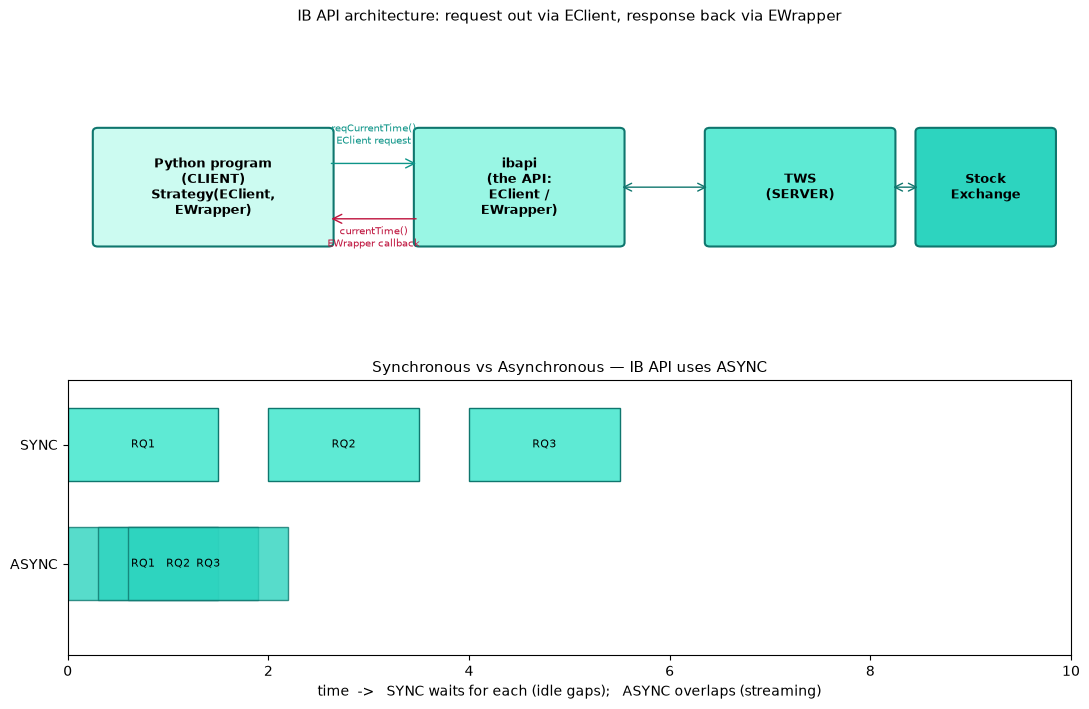

saved chart_1_ibapi.png


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(2, 1, figsize=(11, 7.2), gridspec_kw={"height_ratios":[1.15,1]})

# ---- Panel 1: request/response architecture ----
a = ax[0]; a.axis("off"); a.set_xlim(0,10); a.set_ylim(0,4)
def box(x,y,w,h,txt,fc):
    a.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.05",fc=fc,ec="#0f766e",lw=1.5))
    a.text(x+w/2,y+h/2,txt,ha="center",va="center",fontsize=9,fontweight="bold")
box(0.3,1.3,2.3,1.4,"Python program\n(CLIENT)\nStrategy(EClient,\nEWrapper)","#ccfbf1")
box(3.5,1.3,2.0,1.4,"ibapi\n(the API:\nEClient /\nEWrapper)","#99f6e4")
box(6.4,1.3,1.8,1.4,"TWS\n(SERVER)","#5eead4")
box(8.5,1.3,1.3,1.4,"Stock\nExchange","#2dd4bf")
a.add_patch(FancyArrowPatch((2.6,2.3),(3.5,2.3),arrowstyle="->",mutation_scale=16,color="#0d9488"))
a.text(3.05,2.55,"reqCurrentTime()\nEClient request",ha="center",fontsize=7,color="#0d9488")
a.add_patch(FancyArrowPatch((3.5,1.6),(2.6,1.6),arrowstyle="->",mutation_scale=16,color="#be123c"))
a.text(3.05,1.25,"currentTime()\nEWrapper callback",ha="center",fontsize=7,color="#be123c")
a.add_patch(FancyArrowPatch((5.5,2.0),(6.4,2.0),arrowstyle="<->",mutation_scale=14,color="#0f766e"))
a.add_patch(FancyArrowPatch((8.2,2.0),(8.5,2.0),arrowstyle="<->",mutation_scale=14,color="#0f766e"))
a.set_title("IB API architecture: request out via EClient, response back via EWrapper", fontsize=11)

# ---- Panel 2: sync vs async timeline ----
b = ax[1]; b.set_xlim(0,10); b.set_ylim(-0.5,2.5); b.set_yticks([0.5,1.8]); b.set_yticklabels(["ASYNC","SYNC"])
for i,(s,e) in enumerate([(0,1.5),(2.0,3.5),(4.0,5.5)]):   # sync: gaps = idle waiting
    b.barh(1.8, e-s, left=s, color="#5eead4", edgecolor="#0f766e")
    b.text((s+e)/2,1.8,f"RQ{i+1}",ha="center",va="center",fontsize=8)
for i,(s,e) in enumerate([(0,1.5),(0.3,1.9),(0.6,2.2)]):   # async: overlapping
    b.barh(0.5, e-s, left=s, color="#2dd4bf", edgecolor="#0f766e", alpha=0.8)
    b.text((s+e)/2,0.5,f"RQ{i+1}",ha="center",va="center",fontsize=8)
b.set_xlabel("time  ->   SYNC waits for each (idle gaps);   ASYNC overlaps (streaming)")
b.set_title("Synchronous vs Asynchronous — IB API uses ASYNC", fontsize=11)
plt.tight_layout(); plt.savefig("chart_1_ibapi.png", dpi=110, bbox_inches="tight"); plt.show()
print("saved chart_1_ibapi.png")

## Takeaways
1. **Automation = your validated strategy talking to the broker** via an API to connect, fetch data, place/manage
   orders, and stream quotes. Learn the **manual** path first.
2. **TWS** is IB's desktop terminal; **paper trading** gives live data with simulated fills — ideal for testing.
3. **API = software medium between client (your Python) and server (broker)**; structured request/response. IB's
   ships as the **`ibapi`** Python package.
4. **IB API is asynchronous only** — fire many requests, receive responses any-time/in-parts; essential for
   streaming.
5. **`EClient` makes requests, `EWrapper` receives them via callbacks**, paired one-to-(one-or-more). Combine via
   **`Strategy(EClient, EWrapper)`**; the object is **`app`**.
6. **`app.run()` is the infinite listener** — put it on a **daemon Thread** so the main thread keeps sending. No
   callback defined → response is lost. Use **Spyder/VS Code**, not Jupyter, for real live trading.